캔에 인쇄된 알코올 도수, 당도, pH 값 정보만으로 레드 와인과 화이트 와인을 구별해야 한다.

In [1]:
# 로지스틱 회귀로 분류하기
# 6,497개의 와인 샘플 데이터

import pandas as pd
wine = pd.read_csv('https://bit.ly/wine_csv_data')

wine.head()

,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0


레드/화이트 와인을 구분하는 이진 분류 문제, 화이트 와인이 양성 클래스

In [2]:
# 각 열의 데이터 타입과 누락되 데이터 존재 여부 확인
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   alcohol  6497 non-null   float64
 1   sugar    6497 non-null   float64
 2   pH       6497 non-null   float64
 3   class    6497 non-null   float64
dtypes: float64(4)
memory usage: 203.2 KB


In [3]:
# 열에 대한 간략한 통계 출력
wine.describe()

,alcohol,sugar,pH,class
count,6497.000000,6497.000000,6497.000000,6497.000000
mean,10.491801,5.443235,3.218501,0.753886
std,1.192712,4.757804,0.160787,0.430779
min,8.000000,0.600000,2.720000,0.000000
25%,9.500000,1.800000,3.110000,1.000000
50%,10.300000,3.000000,3.210000,1.000000
75%,11.300000,8.100000,3.320000,1.000000
max,14.900000,65.800000,4.010000,1.000000


알코올 도수와 당도, pH값의 스케일이 다르다.
특성을 표준화해야한다.

In [4]:
# 훈련/테스트 세트로 나누기
data = wine[['alcohol', 'sugar', 'pH']].to_numpy()
target = wine['class'].to_numpy()

In [5]:
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
    data, target, test_size=0.2, random_state=42)

* train_test_split() 함수는 설정값 지정하지 않으면 25%를 테스트 세트로 지정한다.

In [6]:
print(train_input.shape, test_input.shape)

(5197, 3) (1300, 3)


In [ ]:
# 훈련세트 전처리
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

In [9]:
# 로지스틱 회귀 모델 훈련
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

0.7808350971714451
0.7776923076923077


점수가 높지 않다. 모델이 다소 과소적합된 것 같다.
규제 매개변수 값을 바꾸거나, solver 매개변수에서 다른 알고리즘을 선택하거나, 다항 특성을 만들거나..

In [10]:
# 모델을 설명하기 위해 로지스틱 회귀가 학습한 계수와 절편 출력
print(lr.coef_, lr.intercept_)

[[ 0.51268071  1.67335441 -0.68775646]] [1.81773456]


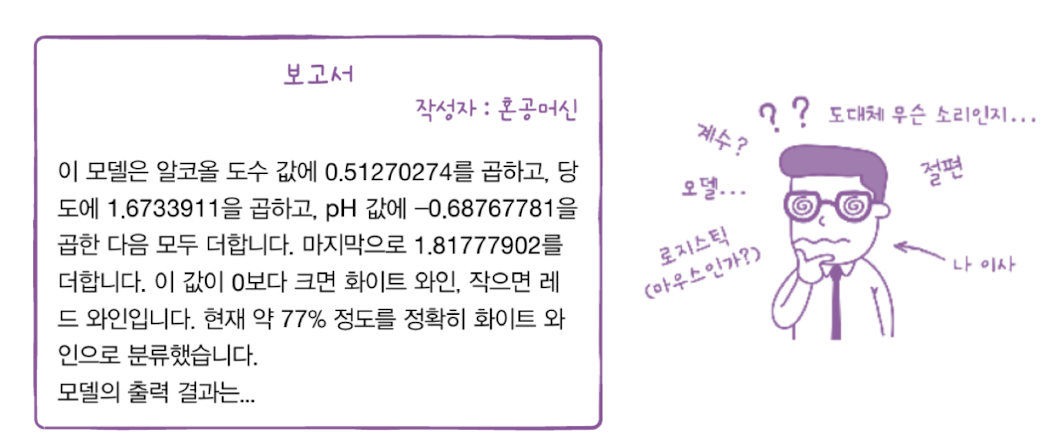

사실 우리는 모델이 왜 저런 계수값을 학습했는지 정확히 이해하기 어렵다.

이유를 설명하기 쉬운 모델은 없을까?

### 결정 트리 (Decision Tree)
데이터를 잘 나눌 수 있는 질문을 하나씩 던져서 정답과 맞춰간다.

In [11]:
# 결정 트리 알고리즘(DecisionTreeClassifier)으로 모델 훈련
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(train_scaled, train_target)

print(dt.score(train_scaled, train_target))
print(dt.score(test_scaled, test_target))

0.996921300750433
0.8592307692307692


훈련세트에 대한 점수 높고, 테스트 세트의 성능은 조금 낮다. 과대적합된 모델.

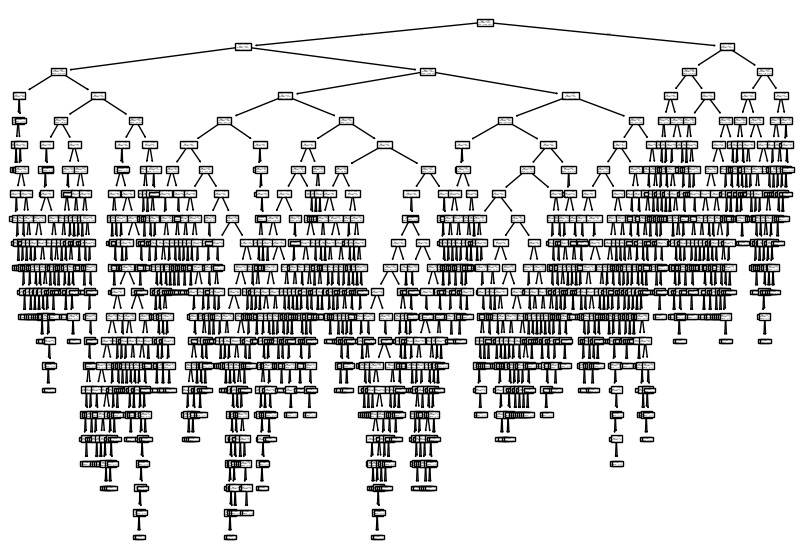

In [12]:
# 모델을 그림으로 표현
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(10,7))
plot_tree(dt)
plt.show()

맨 위의 노드를 루트 노드(root node), 맨 아래 끝에 달린 노드를 리프 노드(leaf node)라고 한다.

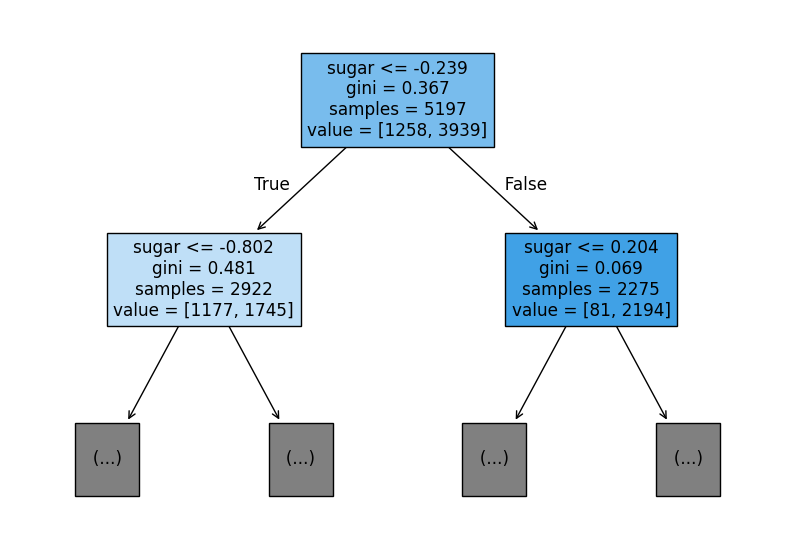

In [13]:
# 트리의 깊이를 제한해서 출력
plt.figure(figsize=(10,7))
plot_tree(dt, max_depth=1, filled=True, 
          feature_names=['alcohol', 'sugar', 'pH'])
plt.show()

맨 윗줄: 테스트 조건, gini: 불순도, samples: 총 샘플 수, value: 클래스별 샘플 수

리프 노드에서 가장 많은 클래스가 예측 클래스가 된다.

#### 불순도(gini)
지니 불순도(Gini impurity)를 의미한다.

criterion 매개변수: 노드에서 데이터를 분할할 기준을 정한다. 기본값이 'gini'

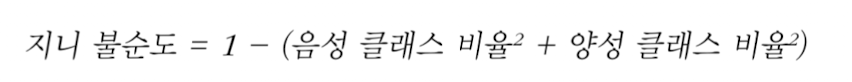

어떤 노드의 두 클래스의 비율이 정확히 1/2씩이라면 지니 불순도는 0.5가 되어 최악이 된다.

노드에 하나의 클래스만 있다면 지니불순도는 0이 되어 가장 작다 = 순수 노드

-> 결정 트리 모델은 부모 노드와 자식 노드의 불순도 차이가 가능한 크도록 트리를 성장시킨다. 둘의 차이를 계산하는 방법은, 먼저 자식 노드의 불순도를 샘플 개수에 비례하여 모두 더한 뒤 부모 노드의 불순도에서 뺀다.

이러한 부모와 자식 노드 사이의 불순도 차이를 **정보 이득(information gain)**이라고 부른다.

**-> 결정 트리는 정보 이득이 최대가 되도록 데이터를 나눈다.**

#### 엔트로피 불순도
노드의 클래스 비율을 사용, 지니 불순도처럼 제곱이 아니라 밑이 2인 로그를 사용하여 곱한다.

지니 불순도와 결과의 차이가 크지 않다.

> 요약: 불순도 기준을 사용해 정보 이득이 최대가 되도록 노드를 분할한다. 노드를 순수하게 나눌수록 정보 이득이 커진다. 새로운 샘플에 대해 예측할 때에는 노드의 질문에 따라 트리를 이동한다. 마지막에 도달한 노드의 클래스 비율을 보고 예측을 만든다.

### 가지치기

In [14]:
# 자라날 수 있는 트리의 최대 깊이 지정하기
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(train_scaled, train_target)

print(dt.score(train_scaled, train_target))
print(dt.score(test_scaled, test_target))

0.8454877814123533
0.8415384615384616


훈련 세트의 성능 낮아졌지만 테스트 세트의 성능은 거의 그대로이다.

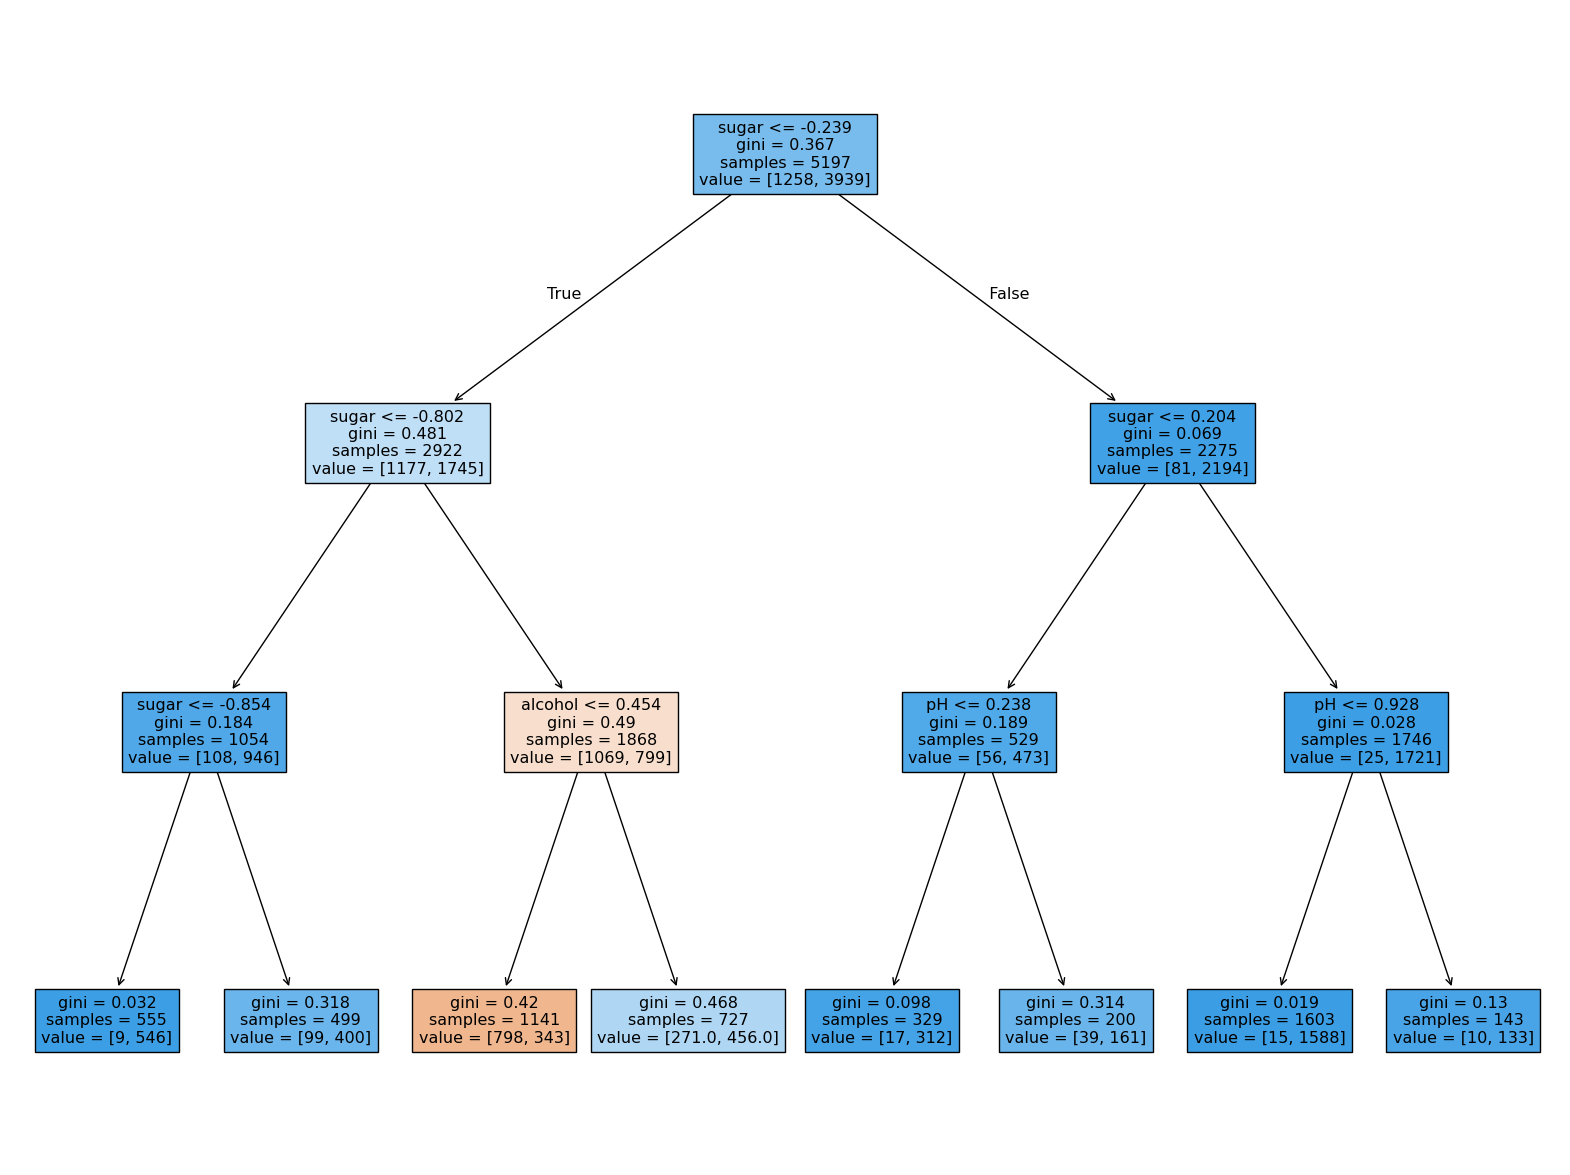

In [15]:
# 트리 그래프로 확인
plt.figure(figsize=(20,15))
plot_tree(dt, filled=True, feature_names=['alcohol', 'sugar', 'pH'])
plt.show()

기준 중 당도 -0.239??

샘플을 어떤 클래스 비율로 나누는지 계산할 때 특성값의 스케일은 계산에 영향을 미치지 않는다. 따라서 표준화 전처리를 할 필요가 없다

In [16]:
# 전처리 이전의 데이터로 다시 결정 트리 모델 훈련
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(train_input, train_target)

print(dt.score(train_input, train_target))
print(dt.score(test_input, test_target))

0.8454877814123533
0.8415384615384616


정확히 동일한 결과

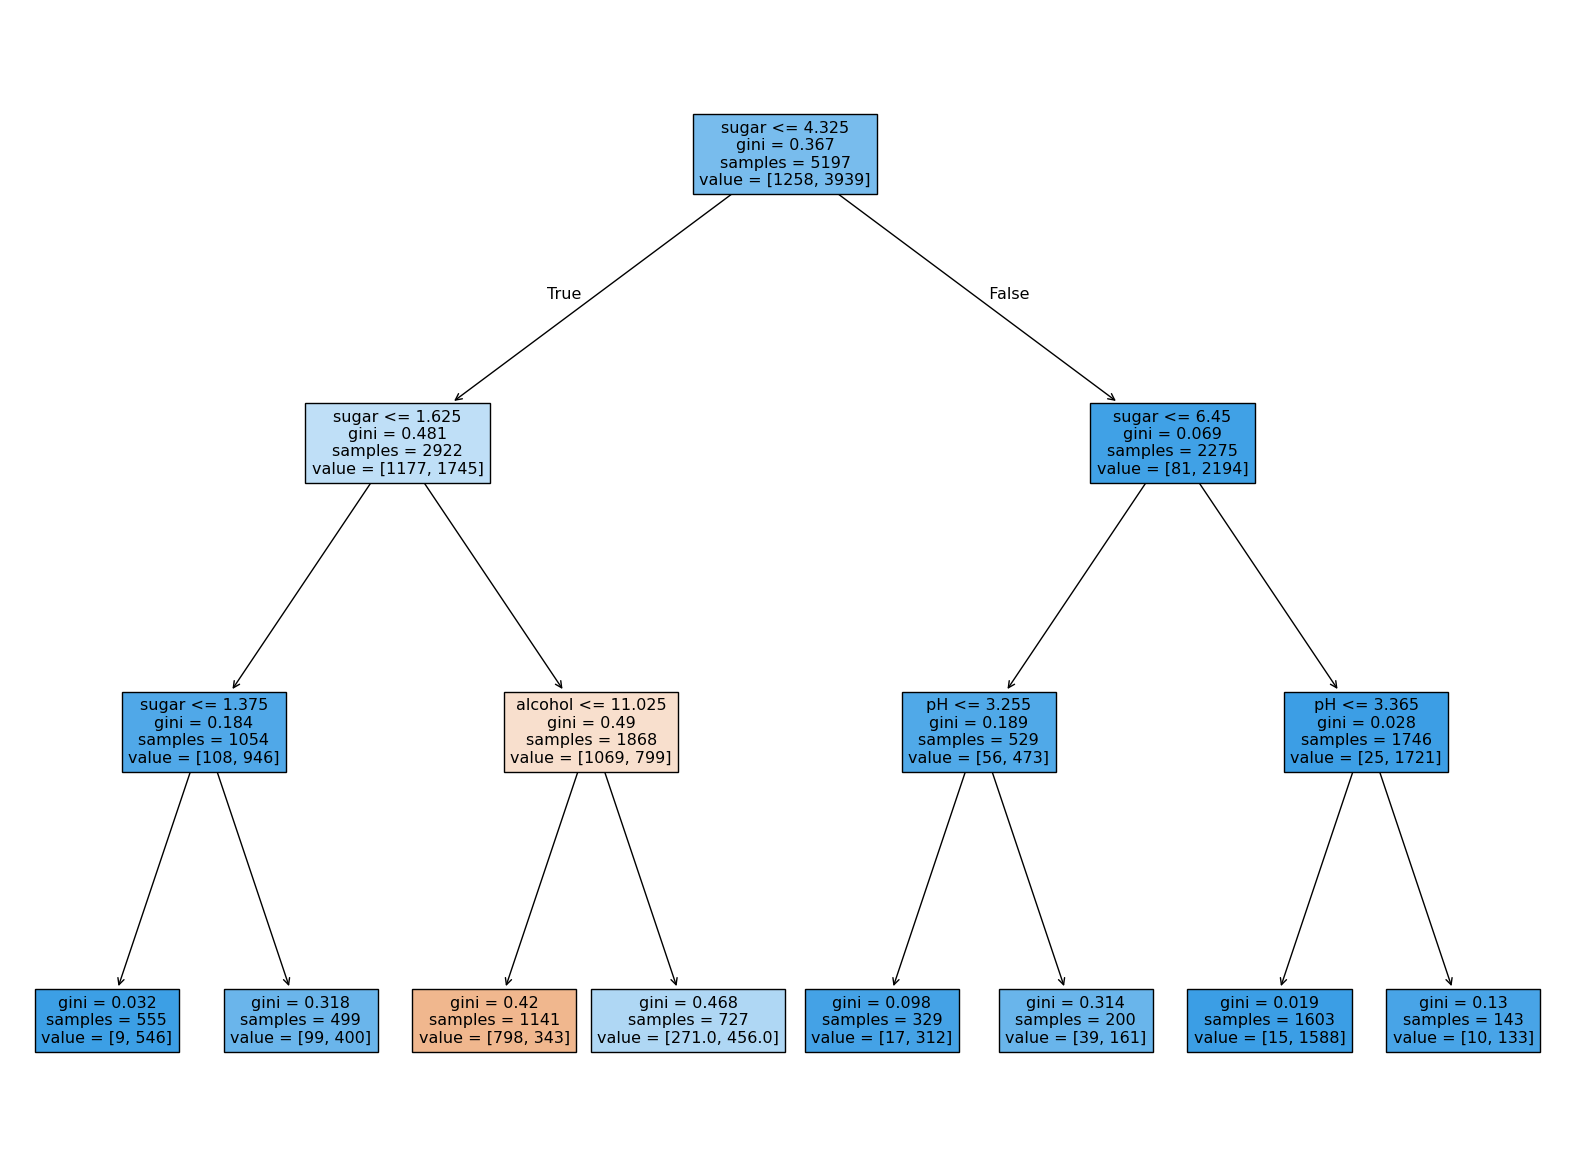

In [17]:
plt.figure(figsize=(20,15))
plot_tree(dt, filled=True, feature_names=['alcohol', 'sugar', 'pH'])
plt.show()

같은 트리이지만 특성값을 표준점수로 바꾸지 않아서 이해하기 쉽다.

In [18]:
# 특성 중요도 확인
print(dt.feature_importances_)

[0.12345626 0.86862934 0.0079144 ]


두 번째 특성인 당도가 0.87 정도로 특성 중요도가 가장 높다. 그다음 알코올 도수, pH 순으로 중요하다. 이들 값을 모두 더하면 1이 된다. 

특성 중요도를 활용해서 결정 트리 모델을 특성 선택에 활용할 수 있다.

# QUESTION.
교재를 보면 비전문가에게도 설명하기 쉬운 모델이라는 설명과 함께 결정 트리에 관한 내용이 등장하는데, 

실제로 그러한 목적에 의해 결정 트리라는 모델이 등장한 것인지, 아니면 개념이 이해하기 쉽다는 것 외에도 다른 목적이나 편의성이 있어서 등장한 것인지 궁금합니다.